In [1]:
import pandas as pd
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [6]:
population_df = pd.read_csv("../dataset/cleaned_population_dataset.csv")
params_df = pd.read_csv("../dataset/cleaned_general_parameters_dataset.csv")
mortality_df = pd.read_csv("../dataset/mortality_parameters_dataset_cleaned.csv")

print(population_df.head())
print(params_df.head())
print(mortality_df.head())

   Year    Age   Sex  Population
0  2000      0  Male     81546.0
1  2000   1-14  Male    618072.5
2  2000  15-64  Male   2709145.5
3  2000  65-89  Male    457217.0
4  2000    90+  Male      9290.0
   Year  Net Migration Rate  Total fertility rate  p_male  p_female
0  2000            0.002200              1.363788  0.5134    0.4866
1  2001            0.004957              1.331394  0.5134    0.4866
2  2002            0.004641              1.389026  0.5134    0.4866
3  2003            0.005462              1.373068  0.5134    0.4866
4  2004            0.006730              1.415371  0.5134    0.4866
   Year    Age     Sex  Mortality Rate
0  2000      0  Female        0.004220
1  2000      0    Male        0.005340
2  2000   1-14  Female        0.000154
3  2000   1-14    Male        0.000183
4  2000  15-64  Female        0.001933


In [8]:
age_groups = ["0", "1-14", "15-64", "65-89", "90+"]
sexes = ["Male", "Female"]

stocks = [(age, sex) for age in age_groups for sex in sexes]
stock_index = {stock: i for i, stock in enumerate(stocks)}

print(stocks)

[('0', 'Male'), ('0', 'Female'), ('1-14', 'Male'), ('1-14', 'Female'), ('15-64', 'Male'), ('15-64', 'Female'), ('65-89', 'Male'), ('65-89', 'Female'), ('90+', 'Male'), ('90+', 'Female')]


In [11]:
start_year = 2000

start_pop = population_df[population_df["Year"] == start_year].copy()

y0 = []

for age, sex in stocks:
    value = start_pop[
        (start_pop["Age"] == age) &
        (start_pop["Sex"] == sex)
    ]["Population"].values[0]
    
    y0.append(value)

y0 = np.array(y0)

print(y0)
print("Initial total population:", y0.sum())

[  81546.    77481.   618072.5  588357.5 2709145.5 2701078.   457217.
  737566.5    9290.    33174. ]
Initial total population: 8012928.0


In [18]:
def get_year(t):
    return int(np.floor(t))

In [23]:
def get_general_params(t):
    year = get_year(t)

    # If solver goes slightly outside available years, clamp to available range
    year = max(params_df["Year"].min(), min(year, params_df["Year"].max()))

    row = params_df[params_df["Year"] == year].iloc[0]

    return {
        "total_fertility_rate": row["Total fertility rate"],
        "net_migration_rate": row["Net Migration Rate"],
        "p_male": row["p_male"],
        "p_female": row["p_female"]
    }

In [42]:
def get_mortality_rate(t, age_group, sex):
    year = get_year(t)

    year = max(mortality_df["Year"].min(), min(year, mortality_df["Year"].max()))

    row = mortality_df[
        (mortality_df["Year"] == year) &
        (mortality_df["Age"] == age_group) &
        (mortality_df["Sex"] == sex)
    ]

    return row["Mortality Rate"].values[0]

In [43]:
def population_ode(t, y):
    dydt = np.zeros_like(y)

    params = get_general_params(t)

    total_fertility_rate = params["total_fertility_rate"]
    net_migration_rate = params["net_migration_rate"]
    p_male = params["p_male"]
    p_female = params["p_female"]

    # Approximation:
    # Total fertility rate is children per woman over reproductive lifetime.
    # We convert it to yearly fertility by dividing by approx. 35 reproductive years.
    yearly_fertility_rate = total_fertility_rate / 35

    female_15_64 = y[stock_index[("15-64", "Female")]]

    total_births = yearly_fertility_rate * female_15_64
    births_male = p_male * total_births
    births_female = p_female * total_births

    for sex in sexes:
        # births by sex
        births = births_male if sex == "Male" else births_female

        # indices
        idx_0 = stock_index[("0", sex)]
        idx_1_14 = stock_index[("1-14", sex)]
        idx_15_64 = stock_index[("15-64", sex)]
        idx_65_89 = stock_index[("65-89", sex)]
        idx_90 = stock_index[("90+", sex)]

        # mortality rates
        mu_0 = get_mortality_rate(t, "0", sex)
        mu_1_14 = get_mortality_rate(t, "1-14", sex)
        mu_15_64 = get_mortality_rate(t, "15-64", sex)
        mu_65_89 = get_mortality_rate(t, "65-89", sex)
        mu_90 = get_mortality_rate(t, "90+", sex)

        # aging rates based on interval widths
        aging_0_to_1_14 = y[idx_0] / 1
        aging_1_14_to_15_64 = y[idx_1_14] / 14
        aging_15_64_to_65_89 = y[idx_15_64] / 50
        aging_65_89_to_90 = y[idx_65_89] / 25

        # age group 0
        dydt[idx_0] += births
        dydt[idx_0] += net_migration_rate * y[idx_0]
        dydt[idx_0] -= mu_0 * y[idx_0]
        dydt[idx_0] -= aging_0_to_1_14

        # age group 1-14
        dydt[idx_1_14] += aging_0_to_1_14
        dydt[idx_1_14] += net_migration_rate * y[idx_1_14]
        dydt[idx_1_14] -= mu_1_14 * y[idx_1_14]
        dydt[idx_1_14] -= aging_1_14_to_15_64

        # age group 15-64
        dydt[idx_15_64] += aging_1_14_to_15_64
        dydt[idx_15_64] += net_migration_rate * y[idx_15_64]
        dydt[idx_15_64] -= mu_15_64 * y[idx_15_64]
        dydt[idx_15_64] -= aging_15_64_to_65_89

        # age group 65-89
        dydt[idx_65_89] += aging_15_64_to_65_89
        dydt[idx_65_89] += net_migration_rate * y[idx_65_89]
        dydt[idx_65_89] -= mu_65_89 * y[idx_65_89]
        dydt[idx_65_89] -= aging_65_89_to_90

        # age group 90+
        dydt[idx_90] += aging_65_89_to_90
        dydt[idx_90] += net_migration_rate * y[idx_90]
        dydt[idx_90] -= mu_90 * y[idx_90]

    return dydt

In [44]:
end_year = 2019

t_eval = np.arange(start_year, end_year + 1)

solution = solve_ivp(
    fun=population_ode,
    t_span=(start_year, end_year),
    y0=y0,
    t_eval=t_eval,
    method="RK45"
)

print(solution.success)
print(solution.message)

True
The solver successfully reached the end of the integration interval.


In [48]:
simulated_df = pd.DataFrame(
    solution.y.T,
    columns=[f"{age}_{sex}" for age, sex in stocks]
)

simulated_df["Year"] = solution.t.astype(int)

simulated_df["simulated_total_population"] = simulated_df[
    [f"{age}_{sex}" for age, sex in stocks]
].sum(axis=1)

simulated_df.head()

,0_Male,0_Female,1-14_Male,1-14_Female,15-64_Male,15-64_Female,65-89_Male,65-89_Female,90+_Male,90+_Female,Year,simulated_total_population
0,81546.000000,77481.000000,618072.500000,588357.500000,2.709146e+06,2.701078e+06,457217.000000,737566.500000,9290.000000,33174.000000,2000,8.012928e+06
1,63691.121805,60498.699865,645842.752056,614668.324550,2.697268e+06,2.692889e+06,459645.521732,726352.904732,21176.724815,47331.261774,2001,8.029365e+06
2,56785.547565,53945.642486,661839.664547,629796.653162,2.693079e+06,2.691922e+06,463331.169810,718853.771537,29267.068081,57157.865773,2002,8.055979e+06
3,55583.795436,52773.882425,673146.371850,640482.659253,2.689033e+06,2.691052e+06,466266.141053,711450.481454,34308.519236,63222.856857,2003,8.077319e+06
4,54811.337568,52015.088408,683305.328679,650046.470625,2.687599e+06,2.692449e+06,469314.170545,704736.893185,38684.132967,67334.568660,2004,8.100296e+06


In [50]:
actual_total = (
    population_df
    .groupby("Year", as_index=False)["Population"]
    .sum()
    .rename(columns={"Population": "actual_total_population"})
)

comparison_df = simulated_df[["Year", "simulated_total_population"]].merge(
    actual_total,
    on="Year",
    how="left"
)

comparison_df["absolute_error"] = abs(
    comparison_df["simulated_total_population"] - comparison_df["actual_total_population"]
)

comparison_df["percentage_error"] = (
    comparison_df["absolute_error"] / comparison_df["actual_total_population"]
) * 100

comparison_df

,Year,simulated_total_population,actual_total_population,absolute_error,percentage_error
0,2000,8.012928e+06,8012928.0,0.000000,0.000000
1,2001,8.029365e+06,8042232.5,12867.470597,0.159999
2,2002,8.055979e+06,8081636.5,25657.193777,0.317475
3,2003,8.077319e+06,8122602.0,45282.795120,0.557491
4,2004,8.100296e+06,8173491.0,73195.443898,0.895522
5,2005,8.138642e+06,8229204.5,90562.697153,1.100504
6,2006,8.173126e+06,8269898.5,96772.133520,1.170173
7,2007,8.185693e+06,8296952.0,111259.202903,1.340965
8,2008,8.196092e+06,8323252.5,127160.629928,1.527776
9,2009,8.206973e+06,8345065.5,138092.031336,1.654775


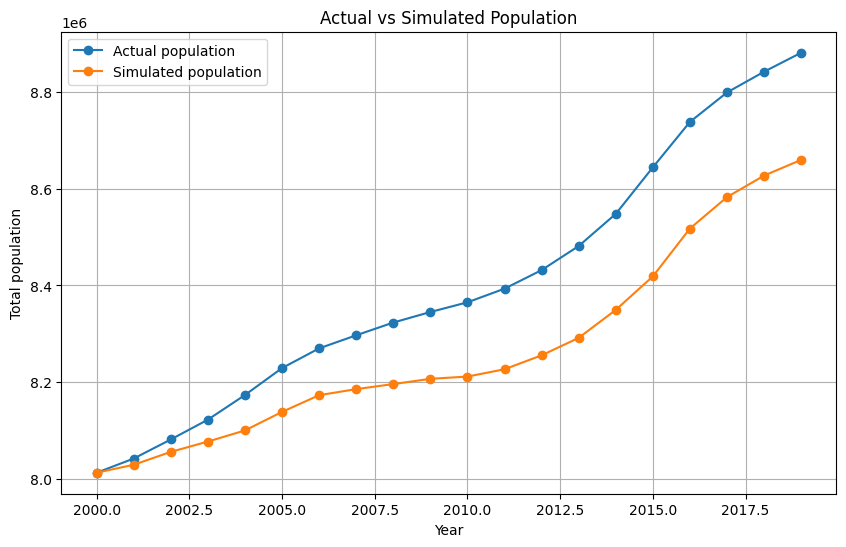

In [52]:
plt.figure(figsize=(10, 6))

plt.plot(
    comparison_df["Year"],
    comparison_df["actual_total_population"],
    marker="o",
    label="Actual population"
)

plt.plot(
    comparison_df["Year"],
    comparison_df["simulated_total_population"],
    marker="o",
    label="Simulated population"
)

plt.xlabel("Year")
plt.ylabel("Total population")
plt.title("Actual vs Simulated Population")
plt.legend()
plt.grid(True)
plt.show()